### **Linear Regression**

In [47]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [48]:
X,y = make_regression(n_samples=200, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

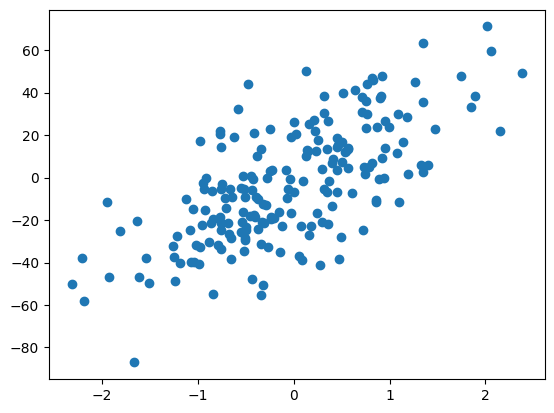

In [49]:
plt.scatter(X,y)
plt.show()

In [50]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X,y)

LinearRegression()

In [51]:
print(LR.coef_)
print(LR.intercept_)

[21.44460094]
-2.0205331651750904


In [52]:
y_pred = LR.predict(X)

In [53]:
from sklearn.metrics import r2_score, mean_squared_error

print("r2_score :",r2_score(y,y_pred))
print("MSE :", np.sqrt(mean_squared_error(y,y_pred)))

r2_score : 0.4721835752792727
MSE : 19.919133422112427


### **Ridge Regression**

In [54]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 10)
ridge.fit(X,y)

Ridge(alpha=10)

In [55]:
print(LR.coef_)
print(LR.intercept_)

[21.44460094]
-2.0205331651750904


In [56]:
ridge1 = Ridge(alpha=100)
ridge1.fit(X,y)
print(ridge1.coef_)
print(ridge1.intercept_)

[13.0141254]
-2.3877150127997


In [64]:
ridge2 = Ridge(alpha=300)
ridge2.fit(X,y)
print(ridge2.coef_)
print(ridge2.intercept_)

[7.2856991]
-2.6372115144617516


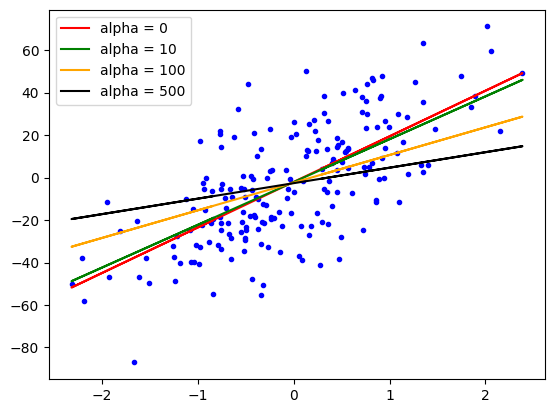

In [65]:
plt.plot(X,y,'b.')
plt.plot(X,LR.predict(X),color = 'red',label = 'alpha = 0')
plt.plot(X,ridge.predict(X),color = 'green',label = 'alpha = 10')
plt.plot(X,ridge1.predict(X),color = 'orange',label = 'alpha = 100')
plt.plot(X,ridge2.predict(X),color = 'black',label = 'alpha = 500')
plt.legend()

### **Creating Regression Class from the Scratch**

In [58]:
X.shape

(200, 1)

In [59]:
class MyRidge:

  def __init__(self,alpha = 10):
    self.alpha = alpha
    self.m = None
    self.b= None

  def fit(self,X_train, y_train):

    num = 0
    den = 0

    for i in range(X_train.shape[0]):
      num = num + (y_train[i] - y_train.mean()) * (X_train[i] - X_train.mean())
      den = den + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())


    self.m = num / (den + self.alpha)
    self.b = y_train.mean() - (self.m * (X_train.mean()))
    print(self.m, self.b)

  def predict(self,X_test):
    pass

In [60]:
reg = MyRidge(alpha = 10)

In [61]:
reg.fit(X,y)

[20.13994678] [-2.07735621]


In [62]:
# we are getting the same results